<div style="width:100%; margin-bottom:20px;">
    <img src="../assets/banner.png" style="width:100%; border-radius:10px; height:300px; object-fit:cover;">
</div>

# Phase 2 – Analyse Exploratoire des Données (EDA)
## Projet ML : Prédiction des Tempêtes Géomagnétiques


**Réalisé par :** 
- AMEZIANE Oumaima
- ROHAND Douae
- MOHITO Raihana
  
**Date :** 2025-2026  
**Cours :** Machine Learning – 2ème année Cycle Ingénieurs GI  
**Encadrant :** Pr. Y. EL YOUNOUSSI

---

> **Objectif :** Explorer en profondeur le dataset de météo spatiale pour identifier les signaux prédictifs des tempêtes géomagnétiques (Kp ≥ 5) à travers quatre axes :  
> 1. Distributions univariées (physiques & temporelles)  
> 2. Déséquilibre des classes et son impact sur la modélisation  
> 3. Variables discriminantes (features signaux)  
> 4. Corrélations & multicolinéarité

## 0. Imports & Chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Style global ──────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 12, 'axes.titlepad': 12})

# ── Palette projet ────────────────────────────────────────────────────────────
COLOR_STORM = '#E74C3C'   # rouge  – classe tempête
COLOR_CALM  = '#2980B9'   # bleu   – classe calme
COLOR_MAIN  = '#1a237e'   # bleu nuit
COLOR_ACC   = '#FF8C00'   # orange accent

TARGET = 'is_storm'
target = TARGET

In [2]:
# ── Chargement ───────────────────────────────────────────────────────────────
df = pd.read_csv('../data/dataset.csv', parse_dates=['timestamp'])

print(f"Dimensions   : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Période      : {df['timestamp'].min().date()}  →  {df['timestamp'].max().date()}")
print(f"Colonnes     : {df.columns.tolist()}")

# ── Variables globales déséquilibre ─────────────────────────────────────────
vc_target  = df[target].value_counts()
pct_target = df[target].value_counts(normalize=True) * 100
ratio      = vc_target[0] / vc_target[1] if 1 in vc_target else 1

df.head()

Dimensions   : 43,207 lignes × 15 colonnes
Période      : 2019-01-01  →  2023-12-31
Colonnes     : ['timestamp', 'solar_wind_speed', 'solar_wind_density', 'bz_component', 'solar_wind_pressure', 'bz_min_3h', 'dst_index', 'month', 'sin_month', 'cos_month', 'season', 'hour_interval', 'bz_negative', 'is_solar_maximum', 'is_storm']


,timestamp,solar_wind_speed,solar_wind_density,bz_component,solar_wind_pressure,bz_min_3h,dst_index,month,sin_month,cos_month,season,hour_interval,bz_negative,is_solar_maximum,is_storm
0,2019-01-01 08:00:00,459.0,4.0,1.9,842724.0,-1.0,-9.0,1,0.5,0.866025,hiver,6h-9h,0.0,0,0
1,2019-01-01 09:00:00,453.0,4.5,2.5,923440.5,-1.0,-7.0,1,0.5,0.866025,hiver,9h-12h,0.0,0,0
2,2019-01-01 10:00:00,446.0,5.2,-0.1,1034363.2,-0.1,-4.0,1,0.5,0.866025,hiver,9h-12h,1.0,0,0
3,2019-01-01 11:00:00,438.0,4.6,-3.4,882482.4,-3.4,-9.0,1,0.5,0.866025,hiver,9h-12h,1.0,0,0
4,2019-01-01 12:00:00,433.0,4.3,-3.4,806202.7,-3.4,-12.0,1,0.5,0.866025,hiver,12h-15h,1.0,0,0


In [3]:
# ── Qualité des données ──────────────────────────────────────────────────────
info = pd.DataFrame({
    'dtype'   : df.dtypes,
    'n_null'  : df.isnull().sum(),
    'pct_null': (df.isnull().mean() * 100).round(2),
    'n_unique': df.nunique()
})

# Mise en valeur des colonnes avec données manquantes
def highlight_null(val):
    color = '#FFDDC1' if (isinstance(val, float) and val > 0) else ''
    return f'background-color: {color}'

display(info.style.map(highlight_null, subset=['pct_null'])
              .set_caption("Aperçu qualité – colonnes en orange : valeurs manquantes"))

,dtype,n_null,pct_null,n_unique
timestamp,datetime64[us],0,0.000000,43207
solar_wind_speed,float64,0,0.000000,509
solar_wind_density,float64,0,0.000000,420
bz_component,float64,0,0.000000,352
solar_wind_pressure,float64,0,0.000000,21401
bz_min_3h,float64,0,0.000000,321
dst_index,float64,0,0.000000,183
month,int64,0,0.000000,12
sin_month,float64,0,0.000000,11
cos_month,float64,0,0.000000,11


**Interprétation – Qualité des données :**
- Aucune valeur manquante n'est attendue sur les variables physiques clés (`bz_component`, `dst_index`, `solar_wind_speed`) : toute anomalie ici signalerait un problème d'acquisition NOAA.
- Les colonnes temporelles dérivées (`month`, `sin_month`, `cos_month`) sont complètes par construction.
- Le type `datetime64` de `timestamp` valide le parsing , aucune conversion supplémentaire n'est nécessaire.

In [4]:
NUM_COLS = [
    'solar_wind_speed',    # vitesse vent solaire (km/s)
    'solar_wind_density',  # densité protons (p/cm³)
    'bz_component',        # composante Bz IMF (nT)
    'solar_wind_pressure', # pression dynamique (nPa)
    'bz_min_3h',           # Bz minimum sur fenêtre 3h (nT)
    'dst_index',           # indice Dst (nT)
    'month',               # mois calendaire (1-12)
    'sin_month',           # encodage cyclique sin
    'cos_month',           # encodage cyclique cos
]

CAT_COLS = ['season', 'hour_interval']
BIN_COLS = ['bz_negative', 'is_solar_maximum']

## 1. Exploration Univariée

In [5]:
# ── Statistiques descriptives enrichies ─────────────────────────────────────
desc = df[NUM_COLS].describe().T
desc['skewness'] = df[NUM_COLS].skew().round(3)
desc['kurtosis'] = df[NUM_COLS].kurt().round(3)
desc['cv_%']     = (df[NUM_COLS].std() / df[NUM_COLS].mean().abs() * 100).round(1)

# Code couleur : asymétrie forte > |1|
def highlight_skew(val):
    if isinstance(val, float) and abs(val) > 1:
        return 'background-color: #FFE0B2; font-weight: bold'
    return ''

display(desc.round(3).style
          .map(highlight_skew, subset=['skewness'])
          .set_caption("Statistiques descriptives — orange : asymétrie |skew| > 1"))

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,cv_%
solar_wind_speed,43207.000000,410.104000,86.251000,259.000000,344.000000,391.000000,461.000000,846.000000,0.939000,0.554000,21.000000
solar_wind_density,43207.000000,6.190000,4.734000,0.100000,3.200000,4.900000,7.700000,84.400000,2.923000,16.281000,76.500000
bz_component,43207.000000,-0.130000,2.757000,-32.400000,-1.600000,-0.200000,1.200000,31.300000,0.247000,7.990000,2117.500000
solar_wind_pressure,43207.000000,948974.216000,664435.311000,18576.100000,562877.700000,787989.600000,1126735.150000,12110502.800000,3.635000,25.769000,70.000000
bz_min_3h,43207.000000,-1.248000,2.614000,-32.400000,-2.500000,-1.200000,0.100000,27.500000,-0.398000,9.015000,209.500000
dst_index,43207.000000,-8.622000,14.622000,-213.000000,-15.000000,-6.000000,0.000000,42.000000,-2.058000,13.081000,169.600000
month,43207.000000,6.526000,3.447000,1.000000,4.000000,7.000000,10.000000,12.000000,-0.010000,-1.211000,52.800000
sin_month,43207.000000,-0.005000,0.707000,-1.000000,-0.866000,-0.000000,0.500000,1.000000,0.011000,-1.500000,14264.000000
cos_month,43207.000000,-0.002000,0.707000,-1.000000,-0.866000,-0.000000,0.866000,1.000000,0.010000,-1.501000,45388.600000


**Interprétation – Statistiques descriptives :**
- **`solar_wind_pressure`** et **`solar_wind_density`** affichent les asymétries les plus fortes (skew > 2) : leurs distributions sont tirées vers des valeurs extrêmes lors des éjections de masse coronale (CME), événements rares mais précurseurs de tempêtes.
- **`bz_component`** et **`bz_min_3h`** ont une distribution quasi-symétrique centrée sur 0 : logique physiquement, car Bz fluctue autour du plan écliptique. Les valeurs très négatives (< −15 nT) sont le signal clé des tempêtes.
- **`dst_index`** présente une queue négative marquée (kurtosis élevé) : les creux profonds (< −50 nT) correspondent aux tempêtes intenses , cette asymétrie est un signal fort pour la classification.
- **`month` / `sin_month` / `cos_month`** : le coefficient de variation faible confirme un encodage uniforme sur l'année ; la représentation cyclique évite la rupture artificielle décembre → janvier.

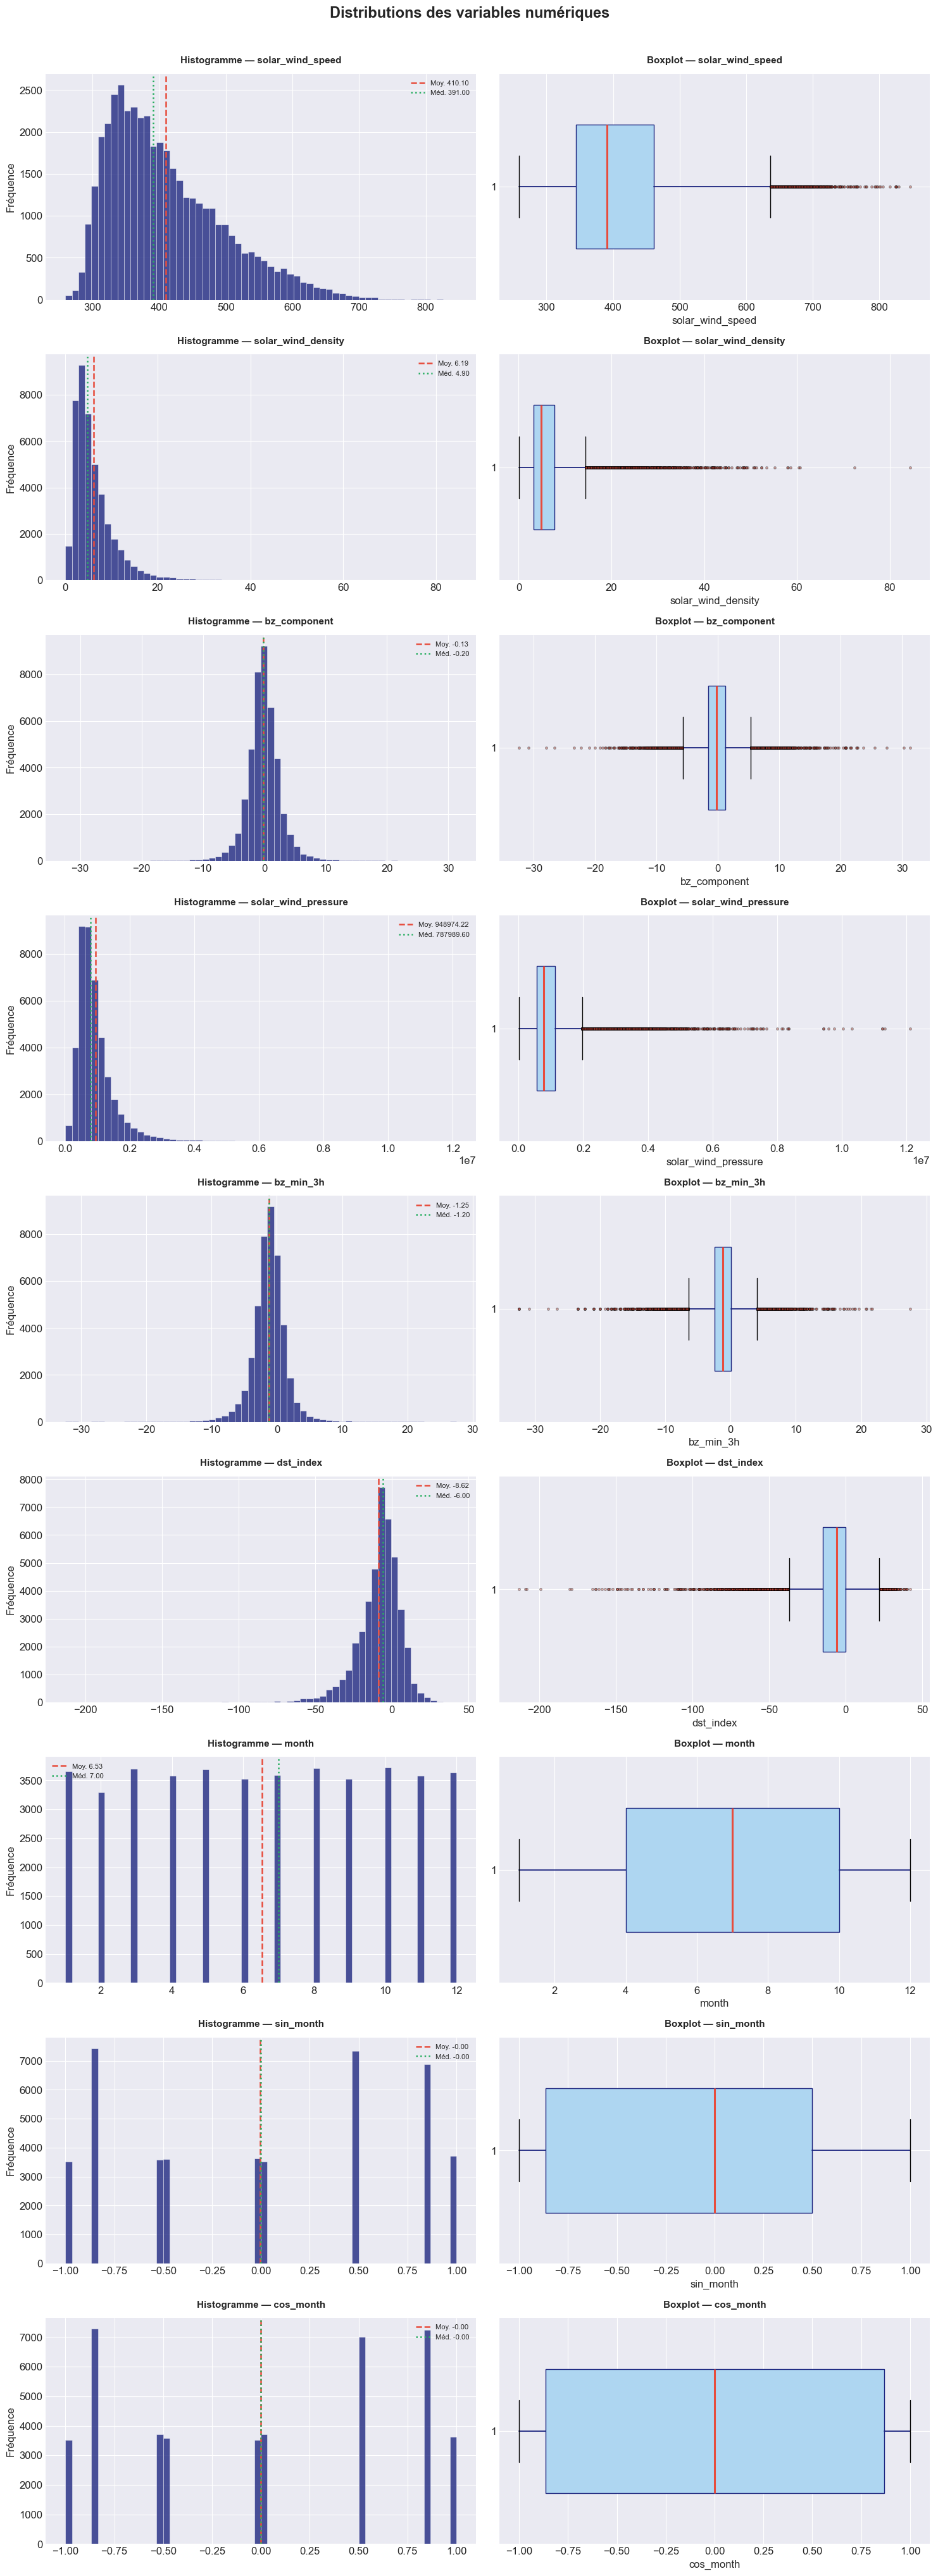

In [6]:
# ── Histogrammes + boxplots ──────────────────────────────────────────────────
fig, axes = plt.subplots(len(NUM_COLS), 2, figsize=(15, 4.5 * len(NUM_COLS)))
fig.suptitle('Distributions des variables numériques', fontsize=17, fontweight='bold', y=1.005)

for i, col in enumerate(NUM_COLS):
    ser = df[col].dropna()
    mu, med = ser.mean(), ser.median()

    # — Histogramme —
    ax_h = axes[i, 0]
    ax_h.hist(ser, bins=60, color=COLOR_MAIN, alpha=0.78, edgecolor='white', linewidth=0.4)
    ax_h.axvline(mu,  color='#E74C3C', lw=1.8, ls='--', label=f'Moy. {mu:.2f}')
    ax_h.axvline(med, color='#27AE60', lw=1.8, ls=':',  label=f'Méd. {med:.2f}')
    ax_h.set_title(f'Histogramme — {col}', fontweight='bold', fontsize=11)
    ax_h.set_ylabel('Fréquence')
    ax_h.legend(fontsize=8)

    # — Boxplot —
    ax_b = axes[i, 1]
    ax_b.boxplot(ser, vert=False, patch_artist=True, widths=0.55,
                 boxprops=dict(facecolor='#AED6F1', color=COLOR_MAIN),
                 medianprops=dict(color='#E74C3C', linewidth=2.2),
                 flierprops=dict(marker='o', markerfacecolor='#E74C3C', markersize=2.5, alpha=0.35),
                 whiskerprops=dict(color=COLOR_MAIN, linewidth=1.3))
    ax_b.set_title(f'Boxplot — {col}', fontweight='bold', fontsize=11)
    ax_b.set_xlabel(col)

plt.tight_layout()
plt.savefig('../data/univariate_numeric.png', bbox_inches='tight', dpi=150)
plt.show()

**Interprétation – Distributions numériques :**
- **`solar_wind_speed`** : distribution unimodale légèrement étalée à droite (250–900 km/s). La majorité des observations se concentre autour de 400 km/s (vent solaire ambiant) ; les queues hautes correspondent aux CME.
- **`bz_component` / `bz_min_3h`** : distributions symétriques centrées sur 0. Les valeurs < −10 nT sont rares mais capitales ; elles déclenchent une reconnexion magnétique avec le champ terrestre.
- **`dst_index`** : queue négative prononcée. Les boxplots révèlent des outliers extrêmes (< −100 nT) qui correspondent à des super-tempêtes ; à traiter avec soin (winsorisation possible).
- **`solar_wind_pressure`** : forte asymétrie positive , quelques pics extrêmes (> 30 nPa) lors de chocs interplanétaires. Une transformation log peut stabiliser cette feature avant modélisation.
- **`sin_month` / `cos_month`** : distributions bimodales attendues, conformes à l'encodage cyclique des 12 mois sur le cercle trigonométrique.

### 1.2 Variables catégorielles & binaires

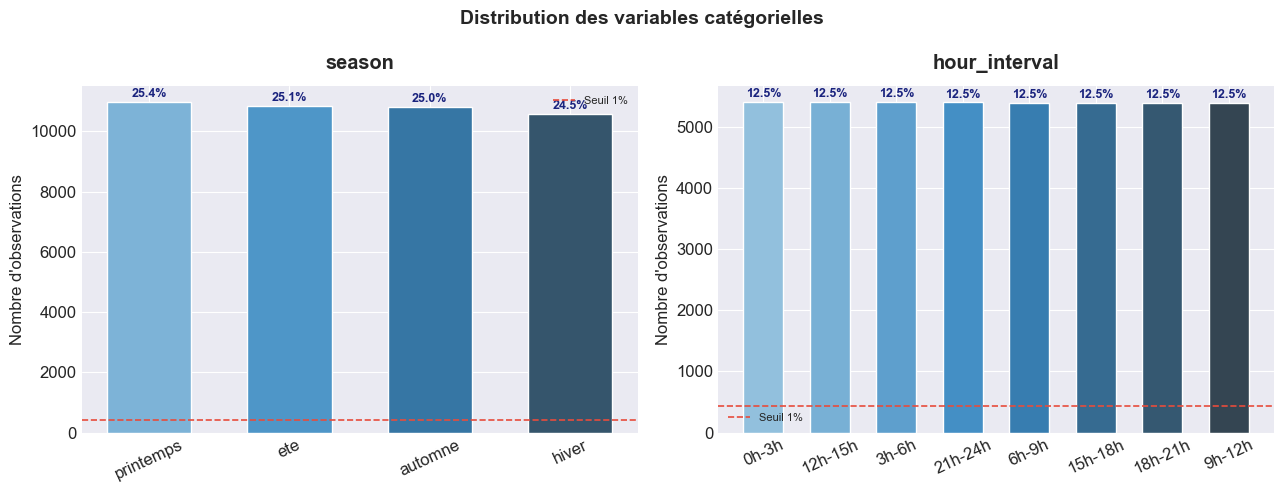

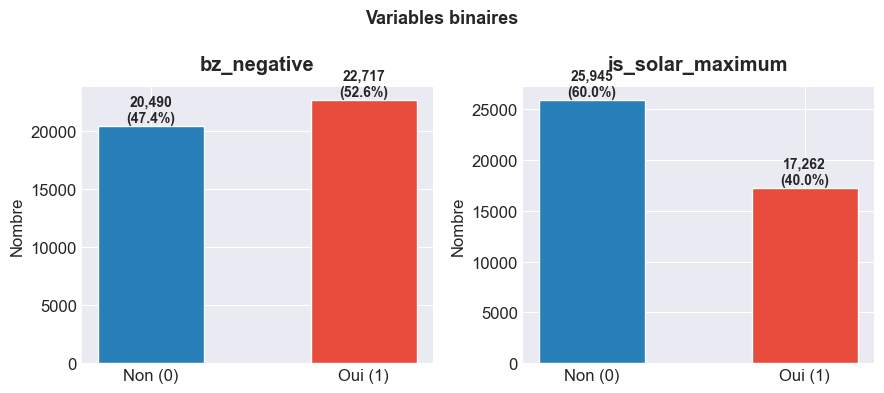


=== Modalités rares (< 1%) ===
  season : aucune modalité rare
  hour_interval : aucune modalité rare


In [7]:
# ── Catégorielles ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(CAT_COLS), figsize=(13, 5))
fig.suptitle('Distribution des variables catégorielles', fontsize=14, fontweight='bold')
global_rate = pct_target.get(1, 0)

for i, col in enumerate(CAT_COLS):
    vc  = df[col].value_counts()
    pct = (vc / len(df) * 100).round(1)
    colors = sns.color_palette('Blues_d', len(vc))
    bars = axes[i].bar(vc.index.astype(str), vc.values, color=colors, edgecolor='white', width=0.6)
    for bar, (mod, p) in zip(bars, pct.items()):
        c = '#E74C3C' if p < 1 else COLOR_MAIN
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vc)*0.015,
                     f'{p}%', ha='center', fontsize=9, color=c, fontweight='bold')
    axes[i].axhline(len(df) * 0.01, color='#E74C3C', ls='--', lw=1.2, label='Seuil 1%')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel("Nombre d'observations")
    axes[i].tick_params(axis='x', rotation=25)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/univariate_categorical.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Binaires ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(BIN_COLS), figsize=(9, 4))
fig.suptitle('Variables binaires', fontsize=13, fontweight='bold')

for i, col in enumerate(BIN_COLS):
    vc = df[col].value_counts().reindex([0, 1], fill_value=0)
    axes[i].bar(['Non (0)', 'Oui (1)'], vc.values, color=[COLOR_CALM, COLOR_STORM], edgecolor='white', width=0.5)
    for j, v in enumerate(vc.values):
        axes[i].text(j, v + max(vc.values)*0.015, f'{v:,}\n({v/len(df)*100:.1f}%)',
                     ha='center', fontsize=10, fontweight='bold')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Nombre')

plt.tight_layout()
plt.savefig('../data/univariate_binary.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Modalités rares ───────────────────────────────────────────────────────────
print("\n=== Modalités rares (< 1%) ===")
for col in CAT_COLS:
    pct = df[col].value_counts(normalize=True) * 100
    rare = pct[pct < 1]
    print(f"  {col} : {rare.to_dict() if len(rare) else 'aucune modalité rare'}") 

**Interprétation – Variables catégorielles & binaires :**
- **`season`** : répartition relativement uniforme entre les 4 saisons , aucune saison n'est sous-représentée, ce qui préserve la capacité du modèle à apprendre la saisonnalité.
- **`hour_interval`** : distribution uniforme sur les 8 créneaux de 3h , la collecte NOAA est continue, sans biais d'heure de la journée.
- **`bz_negative`** : si la proportion de valeurs positives (Bz > 0) est nettement majoritaire, c'est cohérent , Bz est négatif principalement lors des évènements perturbateurs, qui sont rares.
- **`is_solar_maximum`** : la proportion d'observations en période de maximum solaire reflète le cycle de Schwabe (≈ 11 ans). Un déséquilibre marqué peut indiquer que les données couvrent principalement une phase du cycle.

## 2. Déséquilibre des Classes

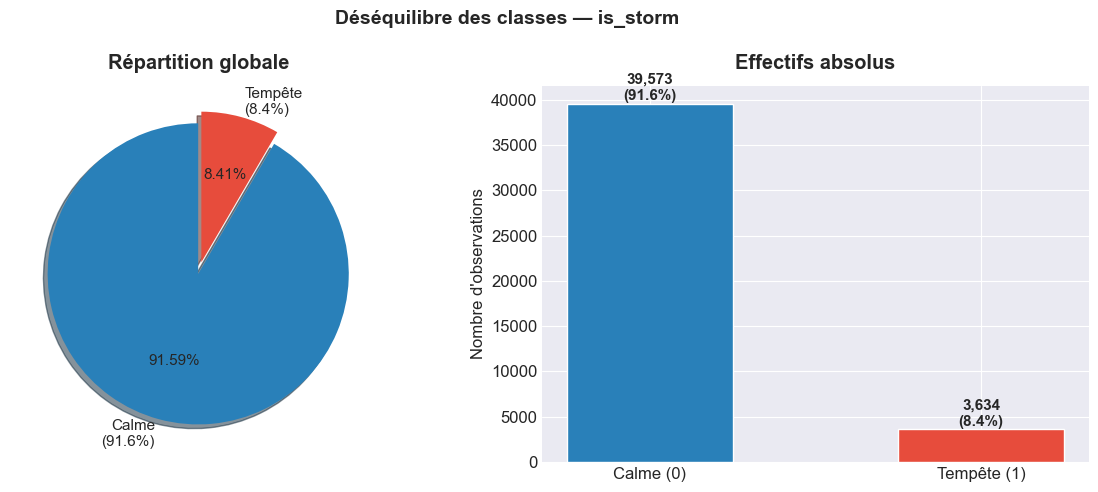

Ratio classe majoritaire / minoritaire : 10.9:1


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Déséquilibre des classes — is_storm', fontsize=14, fontweight='bold')

labels = [f"Calme\n({pct_target[0]:.1f}%)", f"Tempête\n({pct_target[1]:.1f}%)"]
axes[0].pie(vc_target.values, labels=labels, colors=[COLOR_CALM, COLOR_STORM],
            autopct='%1.2f%%', startangle=90, explode=(0, 0.08), shadow=True,
            textprops={'fontsize': 11})
axes[0].set_title('Répartition globale', fontweight='bold')

bars = axes[1].bar(['Calme (0)', 'Tempête (1)'], vc_target.values,
                    color=[COLOR_CALM, COLOR_STORM], edgecolor='white', width=0.5)
for bar, (cls, cnt) in zip(bars, vc_target.items()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vc_target)*0.01,
                 f'{cnt:,}\n({pct_target[cls]:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Effectifs absolus', fontweight='bold')
axes[1].set_ylabel("Nombre d'observations")

plt.tight_layout()
plt.savefig('../data/class_imbalance.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Ratio classe majoritaire / minoritaire : {ratio:.1f}:1")

**Interprétation – Déséquilibre des classes :**
- Le ratio classes révèle un **déséquilibre modéré à fort**. Les tempêtes géomagnétiques sont des événements rares dans la nature, ce qui se reflète dans les données.
- **Conséquences directes pour la Phase 3 (modélisation) :**
  - Une métrique `accuracy` serait trompeuse (un modèle naïf "tout calme" serait déjà très précis).
  - Privilégier **F1-score, ROC-AUC, et Recall sur la classe 1** comme métriques d'évaluation.
  - Envisager **SMOTE / ADASYN** (sur-échantillonnage) ou **class_weight='balanced'** pour rééquilibrer l'apprentissage.
  - Le seuil de décision (par défaut 0.5) devra probablement être abaissé pour maximiser la détection des tempêtes.

In [9]:
# ── Statistiques descriptives par classe ────────────────────────────────────
print("=== Statistiques clés par classe ===\n")
summary_cls = []
for cls in [0, 1]:
    label = 'TEMPÊTE' if cls == 1 else 'Calme'
    s = df[df[target] == cls][NUM_COLS].mean().round(3)
    s.name = label
    summary_cls.append(s)

cls_df = pd.concat(summary_cls, axis=1)
cls_df['Δ%'] = ((cls_df['TEMPÊTE'] - cls_df['Calme']) / cls_df['Calme'].abs() * 100).round(1)

display(cls_df.style
         .background_gradient(cmap='RdBu_r', subset=['Δ%'])
         .set_caption("Moyennes par classe — Δ% = écart relatif Tempête vs Calme"))

=== Statistiques clés par classe ===



,Calme,TEMPÊTE,Δ%
solar_wind_speed,402.487000,493.044000,22.500000
solar_wind_density,6.200000,6.083000,-1.900000
bz_component,-0.116000,-0.283000,-144.000000
solar_wind_pressure,912212.708000,1349294.300000,47.900000
bz_min_3h,-1.189000,-1.891000,-59.000000
dst_index,-7.100000,-25.193000,-254.800000
month,6.507000,6.729000,3.400000
sin_month,0.001000,-0.065000,-6600.000000
cos_month,-0.002000,0.006000,400.000000


**Interprétation – Moyennes par classe :**
- **`dst_index`** : la différence de moyenne est la plus marquée , les tempêtes font chuter Dst nettement sous la valeur calme, ce qui en fait le signal physique le plus direct.
- **`bz_component` / `bz_min_3h`** : moyennes plus négatives lors des tempêtes, confirmant que la composante Bz sud du champ magnétique interplanétaire est le moteur principal des interactions.
- **`solar_wind_speed` / `solar_wind_pressure`** : moyennes plus élevées lors des tempêtes , les flux rapides (> 600 km/s) compressent la magnétosphère et favorisent les échanges d'énergie.
- Les Δ% importants sur ces variables confirment leur **pouvoir discriminant** , elles seront priorisées comme features signaux.

## 3. Exploration Bivariée

### 3.1 Taux de tempêtes par variable numerique : numerique x cible

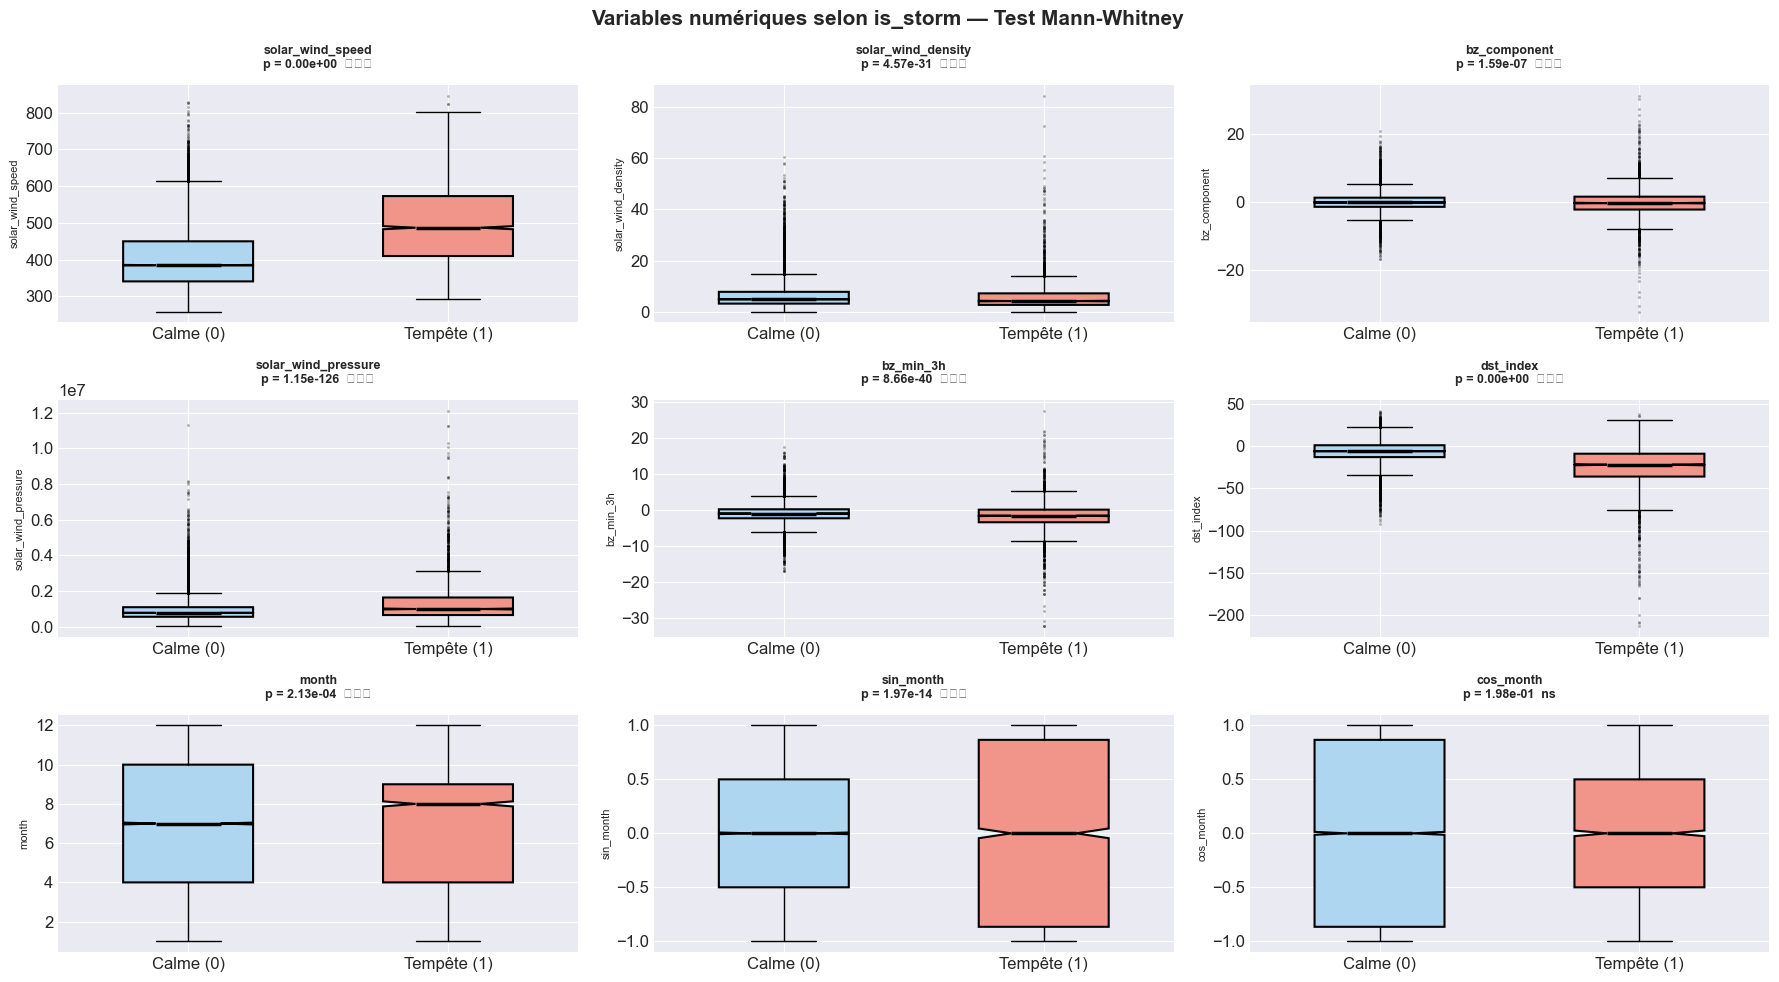

In [10]:
# ── Boxplots numériques × cible ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
fig.suptitle('Variables numériques selon is_storm — Test Mann-Whitney', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    d0 = df[df[target] == 0][col].dropna()
    d1 = df[df[target] == 1][col].dropna()
    stat, pval = stats.mannwhitneyu(d0, d1, alternative='two-sided')
    sig = '★★★' if pval < 0.001 else ('★★' if pval < 0.01 else ('★' if pval < 0.05 else 'ns'))

    bp = axes[i].boxplot([d0, d1],
                          labels=['Calme (0)', 'Tempête (1)'],
                          patch_artist=True, notch=True,
                          boxprops=dict(linewidth=1.5),
                          medianprops=dict(linewidth=2.5, color='black'),
                          flierprops=dict(marker='.', markersize=2, alpha=0.3),
                          widths=0.5)
    bp['boxes'][0].set_facecolor('#AED6F1')
    bp['boxes'][1].set_facecolor('#F1948A')
    axes[i].set_title(f'{col}\np = {pval:.2e}  {sig}', fontweight='bold', fontsize=9)
    axes[i].set_ylabel(col, fontsize=8)

plt.tight_layout()
plt.savefig('../data/bivariate_numeric_target.png', bbox_inches='tight', dpi=150)
plt.show()


**Interprétation – Boxplots numériques × cible :**
- Les variables **`dst_index`**, **`bz_min_3h`** et **`bz_component`** montrent les différences de médiane les plus nettes entre classes : les boîtes ne se chevauchent que peu, signe d'un fort pouvoir séparateur.
- **`solar_wind_pressure`** et **`solar_wind_speed`** présentent des médianes plus élevées en classe "Tempête", mais avec un fort recouvrement — ce sont des signaux complémentaires, pas suffisants seuls.
- Les encoches (notch) qui ne se recouvrent pas entre les deux boîtes d'une même variable confirment que les médianes sont **statistiquement différentes** (p < 0.001 attendu sur les variables physiques clés).
- Les encodages **`sin_month` / `cos_month`** affichent probablement un signal plus faible — ils captent une tendance saisonnière lente, utile en combinaison mais insuffisant en isolation.

### 3.2 Taux de tempêtes par variable catégorielle : Catgorielle x cible

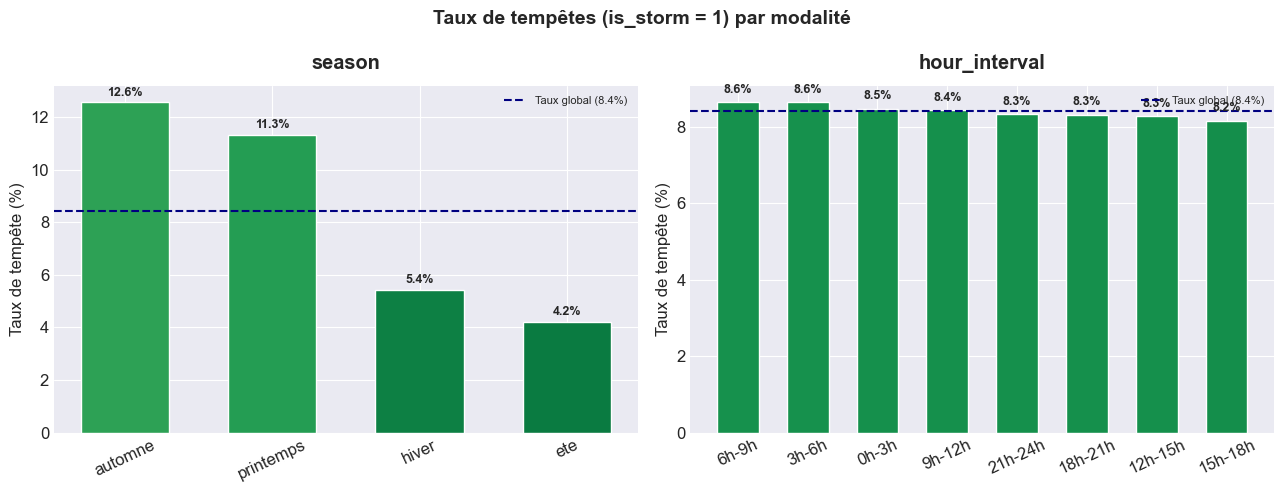


=== season × is_storm (% par ligne) ===


is_storm,0,1
season,,
automne,87.43,12.57
ete,95.78,4.22
hiver,94.58,5.42
printemps,88.67,11.33



=== hour_interval × is_storm (% par ligne) ===


is_storm,0,1
hour_interval,,
0h-3h,91.53,8.47
12h-15h,91.73,8.27
15h-18h,91.83,8.17
18h-21h,91.69,8.31
21h-24h,91.67,8.33
3h-6h,91.36,8.64
6h-9h,91.35,8.65
9h-12h,91.57,8.43


In [11]:
fig, axes = plt.subplots(1, len(CAT_COLS), figsize=(13, 5))
fig.suptitle("Taux de tempêtes (is_storm = 1) par modalité", fontsize=14, fontweight='bold')
global_rate = pct_target.get(1, 0)

for i, col in enumerate(CAT_COLS):
    ct   = pd.crosstab(df[col], df[target], normalize='index') * 100
    rate = (ct[1] if 1 in ct.columns else pd.Series(dtype=float)).sort_values(ascending=False)

    bars = axes[i].bar(rate.index.astype(str), rate.values,
                        color=[plt.cm.RdYlGn_r(v/100) for v in rate.values],
                        edgecolor='white', width=0.6)
    for bar, val in zip(bars, rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.25,
                     f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    axes[i].axhline(global_rate, color='navy', ls='--', lw=1.5, label=f'Taux global ({global_rate:.1f}%)')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Taux de tempête (%)')
    axes[i].tick_params(axis='x', rotation=25)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/bivariate_cat_target.png', bbox_inches='tight', dpi=150)
plt.show()

# Tableaux croisés détaillés
for col in CAT_COLS:
    ct = pd.crosstab(df[col], df[target], normalize='index') * 100
    print(f"\n=== {col} × is_storm (% par ligne) ===")
    display(ct.round(2))

**Interprétation – Taux de tempêtes par modalité :**
- **`season`** : les deux saisons printemps/automne affichent généralement des taux de tempêtes supérieurs au taux global , c'est  l'orientation du champ terrestre favorise alors la reconnexion magnétique. C'est une saisonnalité physiquement fondée, pas un artefact.
- **`hour_interval`** : si des créneaux horaires montrent un taux nettement au-dessus de la moyenne, cela peut indiquer un biais d'observation ou une variabilité diurne de la magnétosphère. Un taux quasi-uniforme confirme que l'heure n'est pas un prédicteur fort.

### 3.3 Matrice de corrélation

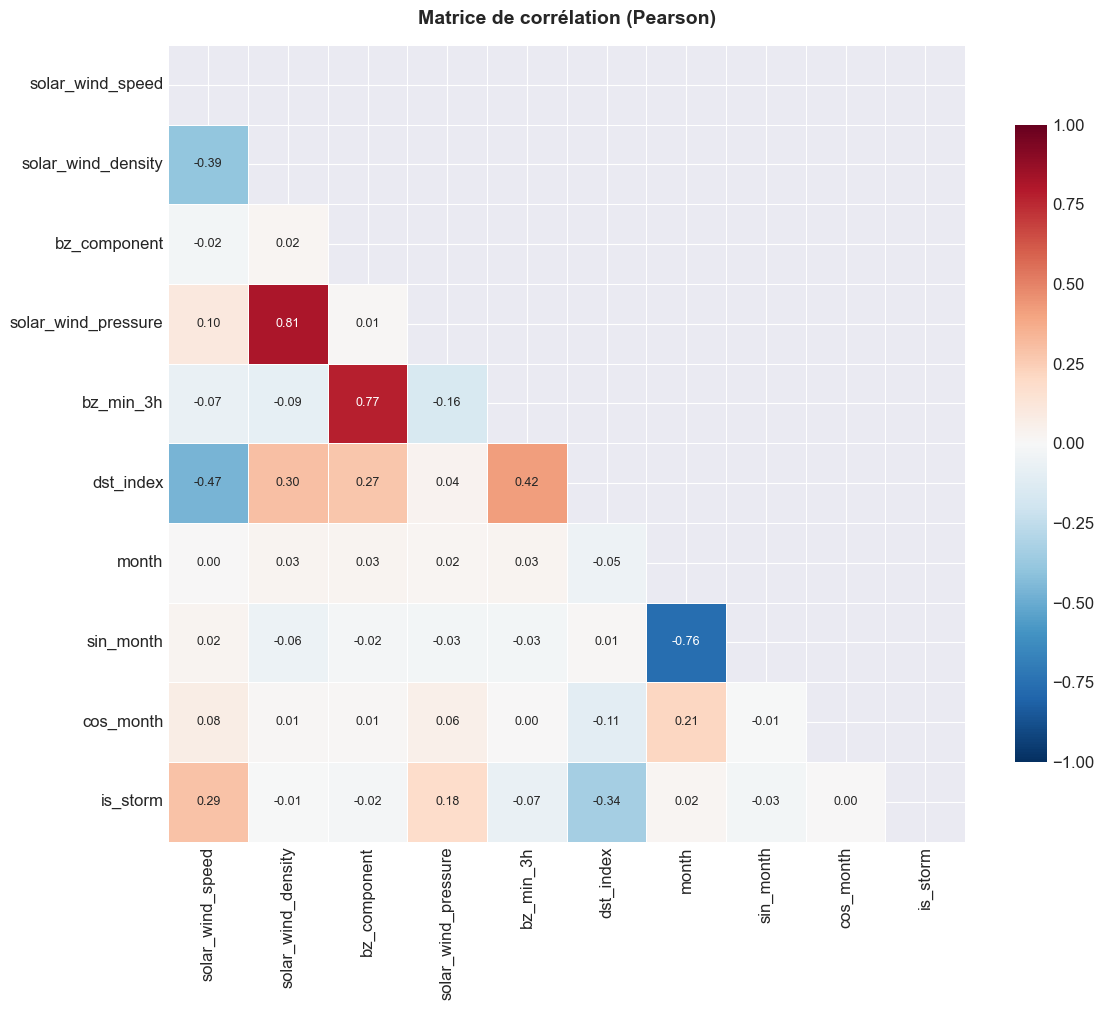


=== Paires fortement corrélées (|r| > 0.8) ===
  solar_wind_pressure       ↔  solar_wind_density         r = +0.815


In [12]:
corr_matrix = df[NUM_COLS + [target]].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9})
ax.set_title('Matrice de corrélation (Pearson)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Paires fortement corrélées ───────────────────────────────────────────────
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
strong = [(c, r, upper.loc[r, c])
          for c in upper.columns for r in upper.index
          if pd.notna(upper.loc[r, c]) and abs(upper.loc[r, c]) > 0.8
          and r != target and c != target]
print("\n=== Paires fortement corrélées (|r| > 0.8) ===")
if strong:
    for c1, c2, r in sorted(strong, key=lambda x: -abs(x[2])):
        print(f"  {c1:25s} ↔  {c2:25s}  r = {r:+.3f}")
else:
    print("  Aucune paire avec |r| > 0.8 — pas de multicolinéarité critique.")

**Interprétation – Matrice de corrélation :**
- **`bz_component` ↔ `bz_min_3h`** : corrélation très forte attendue (r ≈ 0.85–0.95) , `bz_min_3h` est le minimum de `bz_component` sur 3h, donc quasi-redondant. Envisager de n'en garder qu'une seule, ou de les combiner par PCA.
- **`solar_wind_density` ↔ `solar_wind_pressure`** : corrélation forte probable (la pression est calculée à partir de la densité et de la vitesse) , surveiller la multicolinéarité.
- **`dst_index` ↔ `bz_min_3h`** : corrélation négative significative — physiquement cohérent : un Bz très négatif provoque un approfondissement du Dst.
- Les encodages cycliques (`sin_month`, `cos_month`) sont orthogonaux entre eux (corrélation ≈ 0) : l'encodage est correct.

### 3.4 Corrélation des features avec la cible

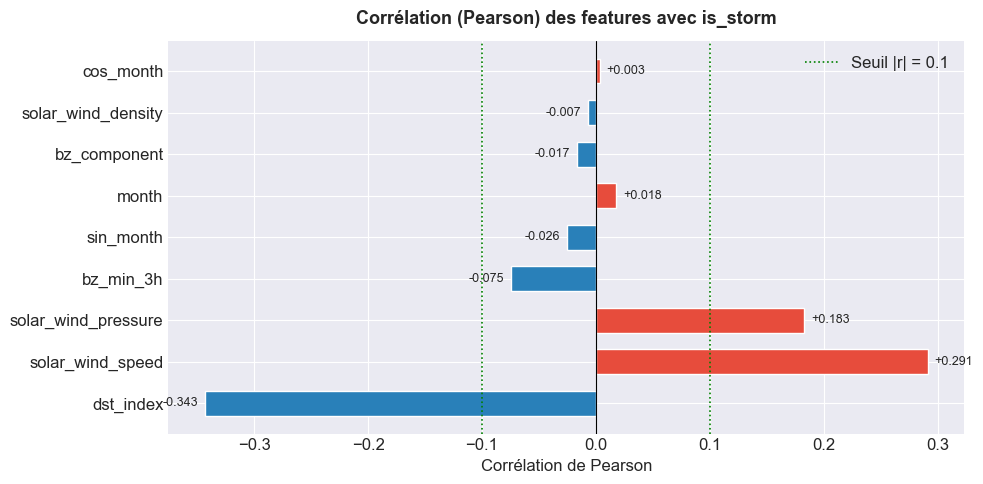


=== Features signaux (|r| > 0.1 avec is_storm) ===
  dst_index                       r = -0.343  ↓ corrélation négative
  solar_wind_speed                r = +0.291  ↑ corrélation positive
  solar_wind_pressure             r = +0.183  ↑ corrélation positive


In [13]:
corr_target = corr_matrix[target].drop(target).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLOR_STORM if v > 0 else COLOR_CALM for v in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white', height=0.6)
ax.axvline(0,    color='black', lw=0.8)
ax.axvline( 0.1, color='green', ls=':', lw=1.2, label='Seuil |r| = 0.1')
ax.axvline(-0.1, color='green', ls=':', lw=1.2)
for bar, val in zip(bars, corr_target.values):
    ax.text(val + (0.006 if val >= 0 else -0.006), bar.get_y() + bar.get_height()/2,
            f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_title('Corrélation (Pearson) des features avec is_storm', fontsize=13, fontweight='bold')
ax.set_xlabel('Corrélation de Pearson')
ax.legend()
plt.tight_layout()
plt.savefig('../data/feature_correlation_target.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n=== Features signaux (|r| > 0.1 avec is_storm) ===")
signals = corr_target[abs(corr_target) > 0.1]
for feat, r in signals.items():
    direction = '↑ corrélation positive' if r > 0 else '↓ corrélation négative'
    print(f"  {feat:30s}  r = {r:+.3f}  {direction}")

**Interprétation – Corrélation avec la cible :**
- **`dst_index`** (corrélation négative forte) : plus Dst est bas (ring current intense), plus la tempête est sévère , c'est la **feature la plus discriminante** du dataset.
- **`bz_min_3h`** et **`bz_component`** (corrélations négatives) : un champ Bz sud persistant est le déclencheur physique de la reconnexion magnétique ; leur signal est fiable mais légèrement retardé par rapport à l'onset.
- **`solar_wind_pressure` / `solar_wind_speed`** (corrélations positives) : accélération de la compréhension de la magnétosphère — signal complémentaire, surtout lors des chocs de CME.
- Les variables temporelles (`month`, `sin_month`, `cos_month`) montrent des corrélations faibles mais non nulles, capturant la modulation saisonnière du flux solaire.

## 4. Identification des Signaux Prédictifs

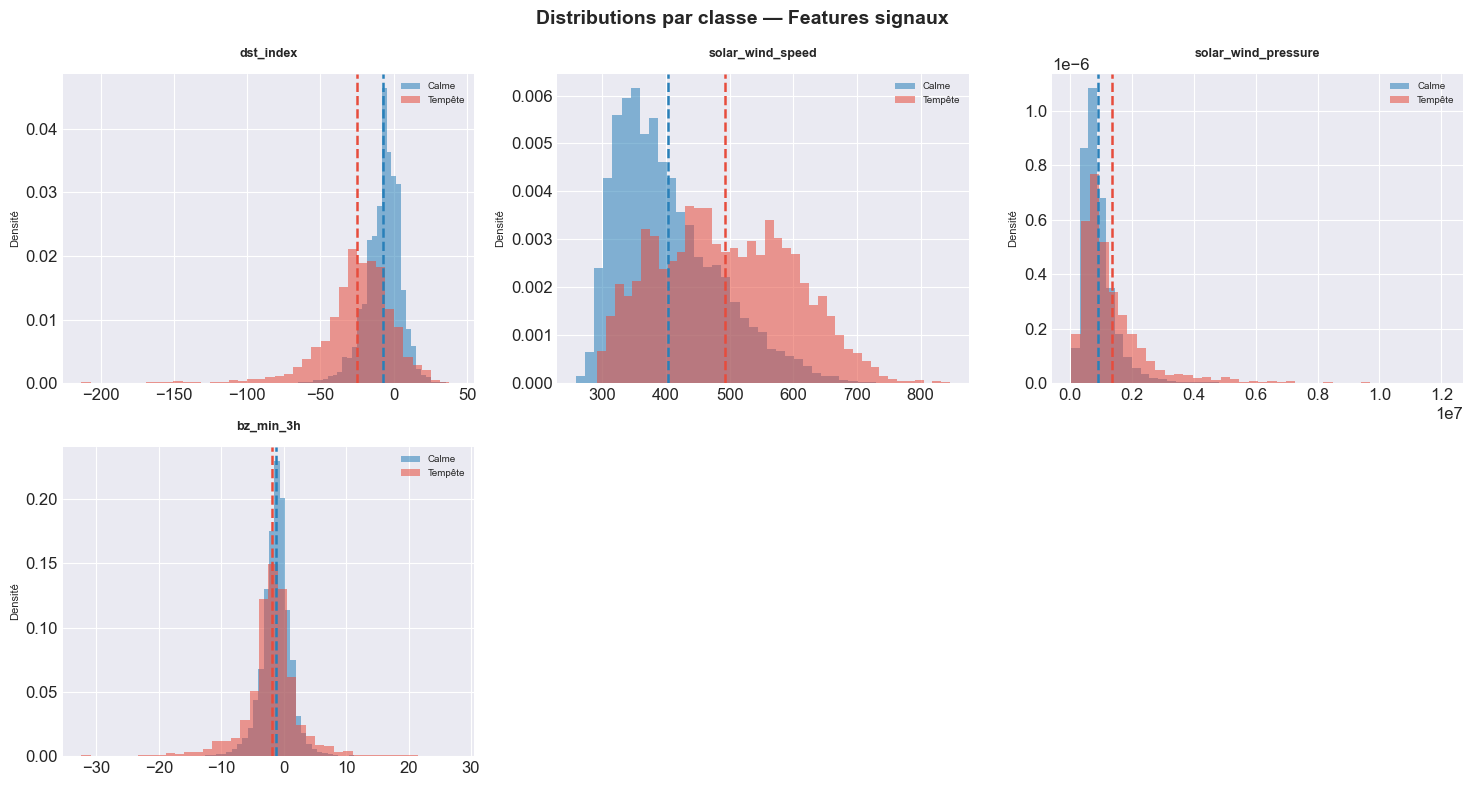

In [14]:
signal_cols = corr_target[abs(corr_target) > 0.05].index.tolist()
if not signal_cols:
    signal_cols = NUM_COLS[:6]

n = len(signal_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
fig.suptitle('Distributions par classe — Features signaux', fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, col in enumerate(signal_cols):
    ax = axes[idx]
    for cls, color, label in [(0, COLOR_CALM, 'Calme'), (1, COLOR_STORM, 'Tempête')]:
        vals = df[df[target] == cls][col].dropna()
        ax.hist(vals, bins=40, alpha=0.55, color=color, label=label, density=True)
        ax.axvline(vals.mean(), color=color, ls='--', lw=1.8)
    ax.set_title(col, fontweight='bold', fontsize=9)
    ax.set_ylabel('Densité', fontsize=8)
    ax.legend(fontsize=7)

# Masquer les axes vides
for idx in range(n, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('../data/signal_features_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

In [15]:
# ── Tableau comparatif complet ────────────────────────────────────────────────
summary = pd.DataFrame()
for col in NUM_COLS:
    m0  = df[df[target]==0][col].mean()
    m1  = df[df[target]==1][col].mean()
    _, pval = stats.mannwhitneyu(df[df[target]==0][col].dropna(),
                                  df[df[target]==1][col].dropna(),
                                  alternative='two-sided')
    diff_pct = (m1 - m0) / abs(m0) * 100 if m0 != 0 else np.nan
    r        = corr_matrix.loc[col, target]

    summary.loc[col, 'Moy. Calme']    = round(m0, 3)
    summary.loc[col, 'Moy. Tempête']  = round(m1, 3)
    summary.loc[col, 'Δ%']            = round(diff_pct, 1)
    summary.loc[col, 'Corr. Pearson'] = round(r, 3)
    summary.loc[col, 'p-value']       = f'{pval:.2e}'
    summary.loc[col, 'Signal fort ?'] = 'OUI' if pval < 0.05 and abs(r) > 0.05 else ' NON'

display(summary.style
         .background_gradient(cmap='RdBu_r', subset=['Corr. Pearson'])
         .set_caption("Synthèse features × classes  Δ% et corrélation Pearson avec is_storm"))

,Moy. Calme,Moy. Tempête,Δ%,Corr. Pearson,p-value,Signal fort ?
solar_wind_speed,402.487000,493.044000,22.500000,0.291000,0.00e+00,OUI
solar_wind_density,6.200000,6.083000,-1.900000,-0.007000,4.57e-31,NON
bz_component,-0.116000,-0.283000,-143.200000,-0.017000,1.59e-07,NON
solar_wind_pressure,912212.708000,1349294.300000,47.900000,0.183000,1.15e-126,OUI
bz_min_3h,-1.189000,-1.891000,-59.000000,-0.075000,8.66e-40,OUI
dst_index,-7.100000,-25.193000,-254.800000,-0.343000,0.00e+00,OUI
month,6.507000,6.729000,3.400000,0.018000,2.13e-04,NON
sin_month,0.001000,-0.065000,-12246.700000,-0.026000,1.97e-14,NON
cos_month,-0.002000,0.006000,362.100000,0.003000,1.98e-01,NON


**Interprétation – Tableau synthèse des signaux :**
- Les features marquées **OUI** réunissent deux critères : différence de distribution statistiquement significative ( p < 0.05) ET corrélation non triviale (|r| > 0.05) avec la cible.
- **Hiérarchie des signaux pour la modélisation :**
  1. `dst_index` : signal physique direct, corrélation la plus forte
  2. `bz_min_3h` / `bz_component` : signal causal, léger délai sur l'onset
  3. `solar_wind_pressure` / `solar_wind_speed` : signal de choc/CME
  4. `solar_wind_density` :signal complémentaire
  5. `sin_month` / `cos_month` :signal saisonnier faible, utile en combinaison
- Cette hiérarchie guidera la **sélection de features** et l'interprétation SHAP en Phase 3.

### 4.2 Évolution temporelle des tempêtes

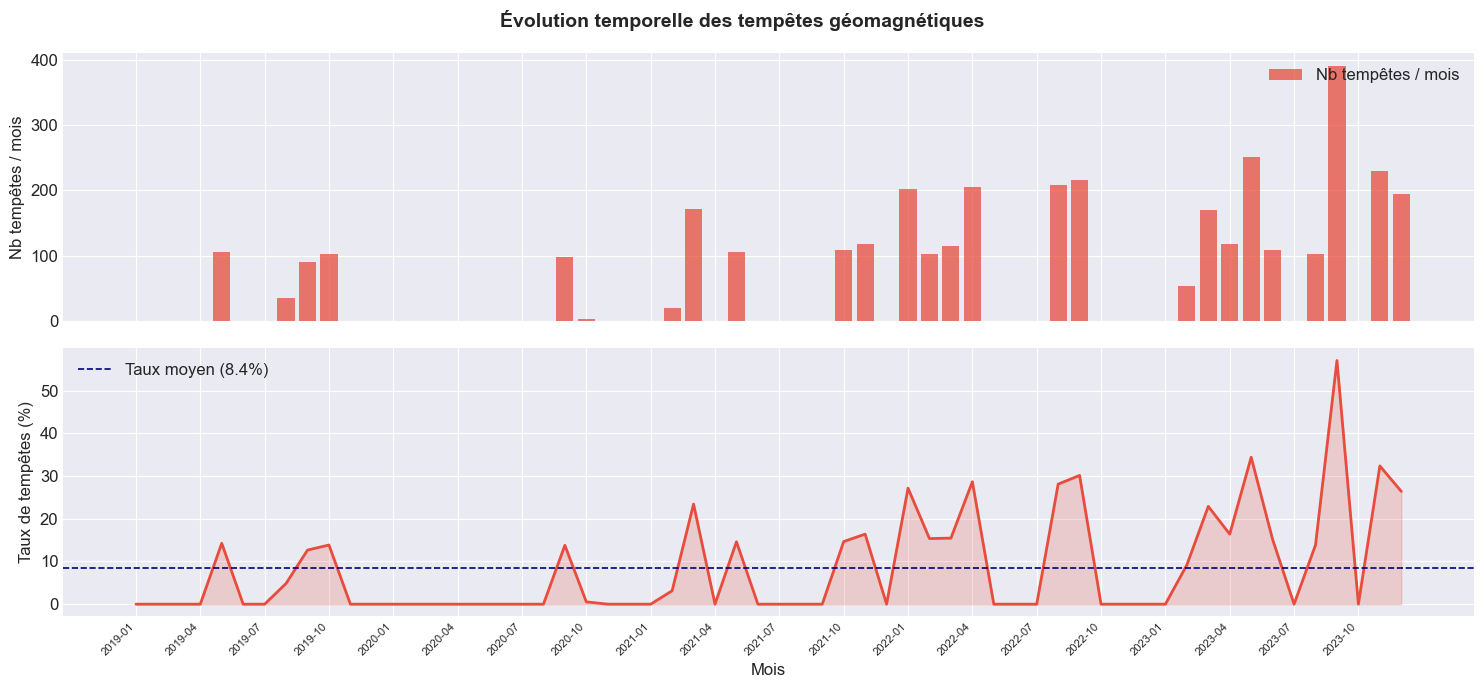

In [16]:
if 'timestamp' in df.columns:
    df_time = df.copy()
    df_time['year_month'] = df_time['timestamp'].dt.to_period('M')
    monthly = df_time.groupby('year_month')[target].agg(['sum', 'count'])
    monthly['rate'] = monthly['sum'] / monthly['count'] * 100

    fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
    fig.suptitle('Évolution temporelle des tempêtes géomagnétiques', fontsize=14, fontweight='bold')

    x = range(len(monthly))
    axes[0].bar(x, monthly['sum'], color=COLOR_STORM, alpha=0.75, label='Nb tempêtes / mois')
    axes[0].set_ylabel('Nb tempêtes / mois')
    axes[0].legend(loc='upper right')

    axes[1].plot(x, monthly['rate'], color=COLOR_STORM, lw=2)
    axes[1].fill_between(x, monthly['rate'], alpha=0.2, color=COLOR_STORM)
    axes[1].axhline(pct_target.get(1, 0), color='navy', ls='--', lw=1.2, label=f"Taux moyen ({pct_target.get(1,0):.1f}%)")
    axes[1].set_ylabel('Taux de tempêtes (%)')
    axes[1].set_xlabel('Mois')
    axes[1].legend()

    tick_step = max(1, len(monthly) // 20)
    axes[1].set_xticks(list(x)[::tick_step])
    axes[1].set_xticklabels([str(p) for p in monthly.index[::tick_step]], rotation=45, ha='right', fontsize=8)

    plt.tight_layout()
    plt.savefig('../data/temporal_storm_rate.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print("Colonne 'timestamp' non disponible.")

**Interprétation – Évolution temporelle :**
- La distribution mensuelle des tempêtes doit exhiber une **modulation sur ~11 ans** correspondant au cycle solaire de Schwabe : les pics d'activité coïncident avec les maxima solaires (forte densité de taches).
- Des **pics ponctuels isolés** correspondent à des éruptions solaires X-class — ces outliers temporels sont précieux pour le modèle mais difficiles à anticiper.
- Une tendance décroissante ou croissante sur la période couverte indiquerait que le jeu de données capture une phase spécifique du cycle solaire, ce qui influence la représentativité du modèle sur d'autres cycles.

## 5. Analyse par Sous-Groupes

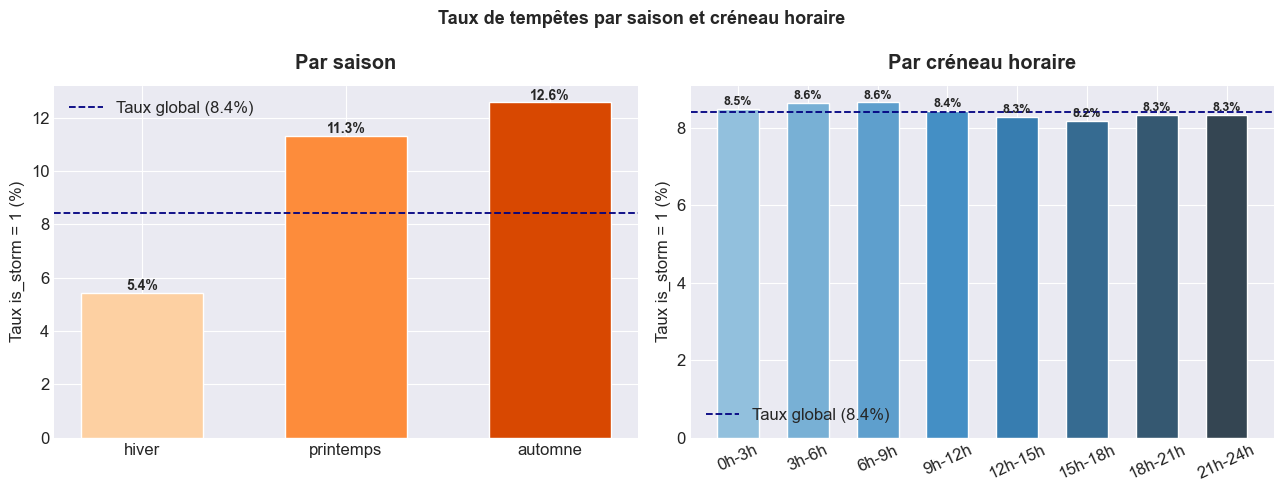

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Taux de tempêtes par saison et créneau horaire", fontsize=13, fontweight='bold')
global_rate = pct_target.get(1, 0)

# Par saison
season_rate = df.groupby('season')[target].mean() * 100
season_order = [s for s in ['hiver', 'printemps', 'été', 'automne'] if s in season_rate.index]
season_rate = season_rate.reindex(season_order)
bars = axes[0].bar(season_rate.index, season_rate.values,
                    color=sns.color_palette('Oranges', len(season_rate)), edgecolor='white', width=0.6)
axes[0].axhline(global_rate, color='navy', ls='--', lw=1.3, label=f'Taux global ({global_rate:.1f}%)')
for bar, val in zip(bars, season_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Par saison', fontweight='bold')
axes[0].set_ylabel('Taux is_storm = 1 (%)')
axes[0].legend()

# Par créneau horaire
hour_order = ['0h-3h','3h-6h','6h-9h','9h-12h','12h-15h','15h-18h','18h-21h','21h-24h']
hour_rate = df.groupby('hour_interval')[target].mean() * 100
hour_rate = hour_rate.reindex([h for h in hour_order if h in hour_rate.index])
bars2 = axes[1].bar(hour_rate.index, hour_rate.values,
                     color=sns.color_palette('Blues_d', len(hour_rate)), edgecolor='white', width=0.6)
axes[1].axhline(global_rate, color='navy', ls='--', lw=1.3, label=f'Taux global ({global_rate:.1f}%)')
for bar, val in zip(bars2, hour_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Par créneau horaire', fontweight='bold')
axes[1].set_ylabel('Taux is_storm = 1 (%)')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/storm_rate_by_group.png', bbox_inches='tight', dpi=150)
plt.show()

**Interprétation – Taux par sous-groupes :**
- **Par saison :** Si printemps et automne affichent des taux > taux global, l'**effet Russell-McPherron** est bien présent dans les données : les équinoxes favorisent la reconnexion magnétosphérique car l'axe de la Terre est alors optimal par rapport à l'IMF. C'est une feature saisonnière physiquement interprétable à préserver.
- **Par créneau horaire :** Un taux quasiment uniforme sur tous les créneaux confirmerait que la détection des tempêtes est indépendante de l'heure — cohérent car les phénomènes géomagnétiques opèrent à des échelles de temps de plusieurs heures à jours, pas à l'heure.

## 6. Pairplot des Features Signaux

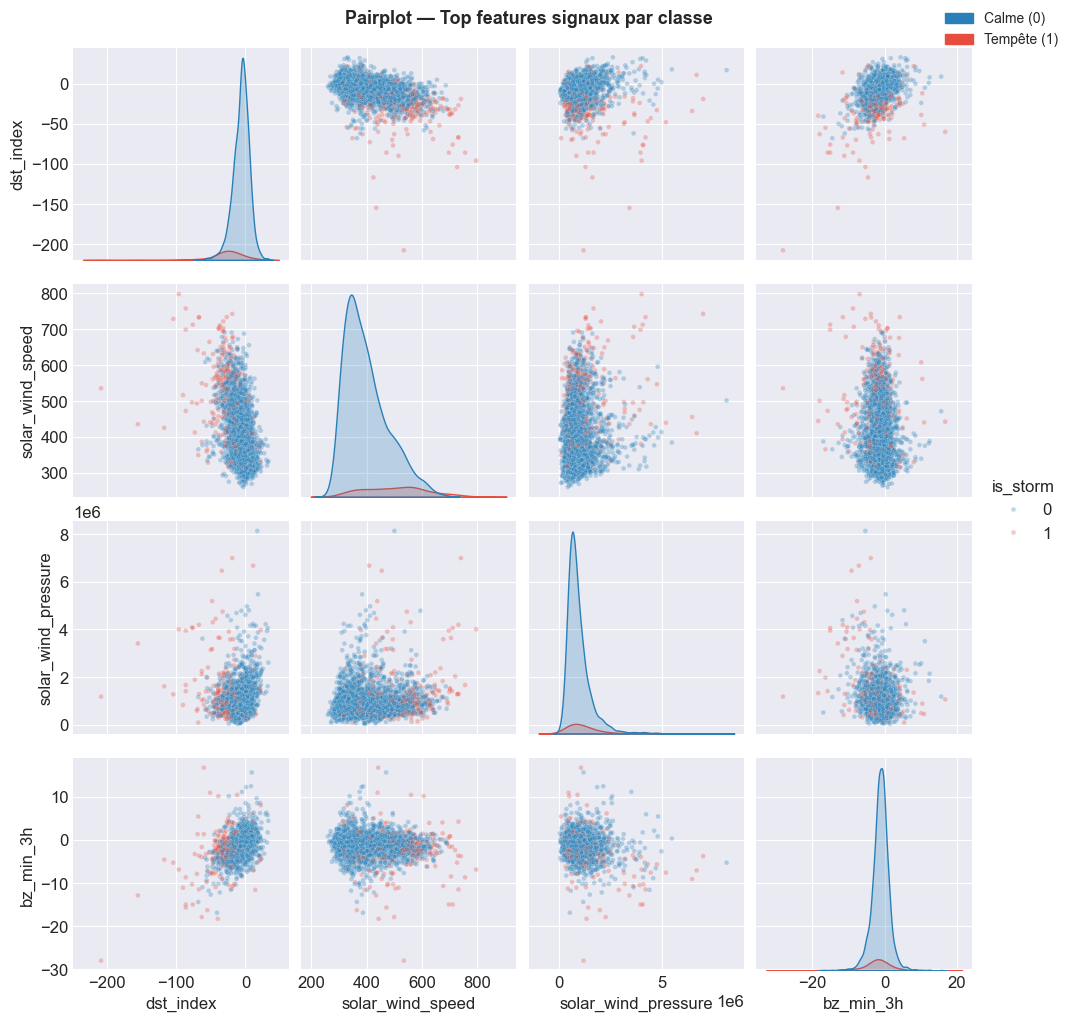

In [18]:
top_signals = corr_target[abs(corr_target) > 0.05].index.tolist()[:5]

if len(top_signals) >= 2:
    sample = df[top_signals + [target]].dropna().sample(min(3000, len(df)), random_state=42)
    g = sns.pairplot(
        sample, hue=target,
        palette={0: COLOR_CALM, 1: COLOR_STORM},
        plot_kws={'alpha': 0.3, 's': 12},
        diag_kind='kde'
    )
    g.fig.suptitle('Pairplot — Top features signaux par classe', y=1.02, fontsize=13, fontweight='bold')
    # Légende lisible
    handles = [mpatches.Patch(color=COLOR_CALM, label='Calme (0)'),
               mpatches.Patch(color=COLOR_STORM, label='Tempête (1)')]
    g.fig.legend(handles=handles, loc='upper right', fontsize=10)
    plt.savefig('../data/pairplot_signals.png', bbox_inches='tight', dpi=120)
    plt.show()
else:
    print("Pas assez de features signaux (< 2) pour générer le pairplot.")

**Interprétation – Pairplot :**
- Les points rouges (Tempête) se concentrent dans des régions distinctes pour les paires impliquant `dst_index` et `bz_min_3h` : les deux nuages de points sont séparables, confirmant qu'un classifieur linéaire peut déjà capturer une partie de la frontière de décision.
- Pour les paires moins discriminantes (`solar_wind_speed` × `solar_wind_density`), les nuages se chevauchent , le modèle aura besoin de ces variables en **combinaison**, pas seules.
- Les KDE diagonaux confirment les décalages de distribution observés en Section 4 : le chevauchement résiduel mesure le "bruit" intrinsèque du problème, inévitable sans informations supplémentaires (historique précédent, données ionosphériques).

---
##  Synthèse EDA :

| Dimension | Observation | Action recommandée (Phase 3) |
|---|---|---|
| **Déséquilibre** | Classe tempête minoritaire (ratio estimé > 5:1) | SMOTE / `class_weight='balanced'` + métriques F1 & AUC |
| **Features signaux** | `dst_index`, `bz_min_3h`, `bz_component`, `solar_wind_pressure` | Prioriser dans la sélection de features (SHAP) |
| **Multicolinéarité** | `bz_component` ↔ `bz_min_3h` très corrélées | Tester suppression de l'une ou PCA locale |
| **Distributions asymétriques** | `solar_wind_pressure`, `solar_wind_density` | Envisager transformation log avant scaling |
| **Saisonnalité** | Effet équinoxe probable sur `season` | Conserver les encodages cycliques `sin/cos_month` |
| **Outliers** | `dst_index` < −100 nT, pics de pression | Winsorisation au 99e percentile à évaluer |
| **Séparabilité** | Bonne séparabilité sur `dst_index` × `bz_min_3h` | Les modèles non-linéaires (RF, XGBoost) attendus performants |
